# 绘制并拟合INP浓度分布图

包括箱形图, 小提琴图, 数据分布图以及在此基础上的拟合

In [2]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import curve_fit

In [ ]:
# 数据读取与预处理
df = pd.read_csv(r'D:\Coding\master0_2025\Lanzhou_cfdc\N_INP(202409-202509)v2.0.csv')
## 将日期设为索引
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
## 增加1列
def activation_temperature(temp: pd.Series):
    if abs(temp - (-15)) < 2.5:
        return -15
    elif abs(temp - (-20)) < 2.5:
        return -20
    elif abs(temp - (-25)) < 2.5:
        return -25
    elif abs(temp - (-30)) < 2.5:
        return -30
    elif abs(temp - (-35)) < 2.5:
        return -35
    else:
        return np.nan
df['T_a(°C)'] = df['T_inp(°C)'].apply(activation_temperature)
## 解决不显示的问题：中文设置为宋体格式
plt.rcParams['font.family'] = ["Times New Roman", 'SimSun']
## 数据预处理（质量控制）
df_selected = df[df['N_inp_net(#/L)'] > 0]
df_selected = df_selected[df_selected['SS_w'] > 4]# 师兄认为需要剔除 SS_w<4 的数据
#df_selected = df_selected[df_selected['season'] == 'Winter']
print(f"总点数量: {df.shape[0]}")
print(f"有效点数量: {df_selected.shape[0]}")
print(f"无效点数量: {df.shape[0] - df_selected.shape[0]}") 

总点数量: 4371
有效点数量: 3143
无效点数量: 1228


## 全年数据

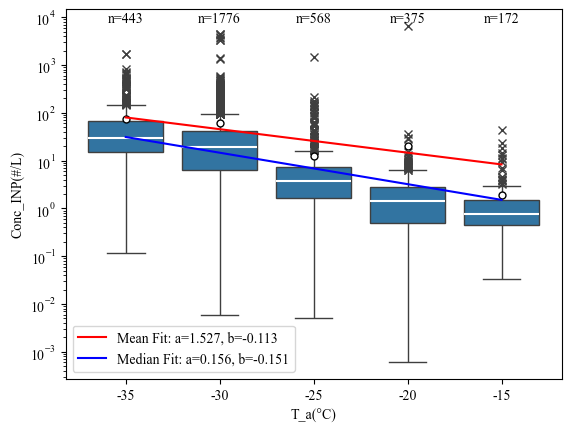

In [3]:
# 用seaborn绘制活化温度箱型图， 并用scipy拟合

def func(T, a, b):
        return a * np.exp(b * T)

mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, bounds=([0, -np.inf], [np.inf, 0]))

temp_order = [-35, -30, -25, -20, -15]
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
sns.boxplot(data=df_selected, x='T_a(°C)', y='N_inp_net(#/L)',
                order=temp_order,
                ax=ax,
                showmeans=True,
                meanprops={"marker":"o",
                        "markerfacecolor":"white",
                        "markeredgecolor":"black",
                        "markersize":"5"},
                flierprops={"marker": "x"},
                medianprops={'color':'white', 'linewidth':1.5}
                    )

x_pos = np.arange(len(temp_order))          # 0..4（分类位置）
y1 = func(mean_inp.index, *popt1)
y2 = func(median_inp.index, *popt2)
ax.plot(x_pos, y1, 'r-', zorder=10,
        label='Mean Fit: a=%5.3f, b=%5.3f' % tuple(popt1))
ax.plot(x_pos, y2, 'b-', zorder=10,
        label='Median Fit: a=%5.3f, b=%5.3f' % tuple(popt2))

for j, temp in enumerate(temp_order):
        count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
        ax.text(j, ax.get_ylim()[1]*1, f'n={count}', ha='center', va='bottom')
ax.set_yscale('log')
ax.set_ylabel('Conc_INP(#/L)')
ax.legend()

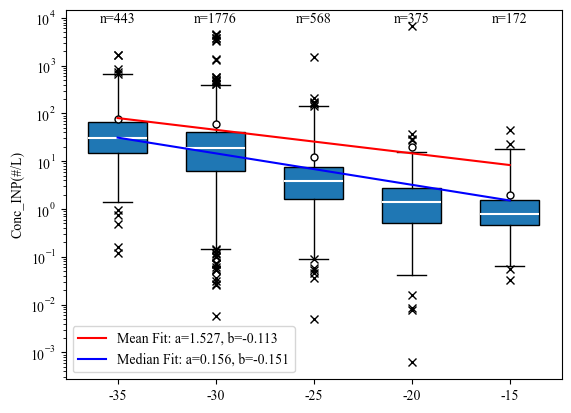

In [4]:
# 使用matplotlib绘制活化温度箱型图， 并用scipy拟合

def func(T, a, b):
    return a * np.exp(b * T)

mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, bounds=([0, -np.inf], [np.inf, 0]))

temp_order = [-35, -30, -25, -20, -15]
data_for_box = [df_selected[df_selected['T_a(°C)'] == t]['N_inp_net(#/L)'] for t in temp_order]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

box = ax.boxplot(
    data_for_box,
    tick_labels=temp_order,
    showmeans=True,
    meanprops={"marker": "o",
               "markerfacecolor": "white",
               "markeredgecolor": "black",
               "markersize": 5},
    flierprops={"marker": "x"},
    medianprops={'color': 'white', 'linewidth': 1.5},
    patch_artist=True,
    positions=temp_order,
    widths=3,
    whis=[1, 99]
)

x1 = mean_inp.index
x2 = median_inp.index
y1 = func(mean_inp.index, *popt1)
y2 = func(median_inp.index, *popt2)
ax.plot(x1, y1, 'r-', zorder=10,
        label='Mean Fit: a=%5.3f, b=%5.3f' % tuple(popt1))
ax.plot(x2, y2, 'b-', zorder=10,
        label='Median Fit: a=%5.3f, b=%5.3f' % tuple(popt2))

for temp in temp_order:
    count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
    ax.text(temp, ax.get_ylim()[1] * 1, f'n={count}', ha='center', va='bottom')

ax.set_yscale('log')
ax.set_ylabel('Conc_INP(#/L)')
ax.legend()

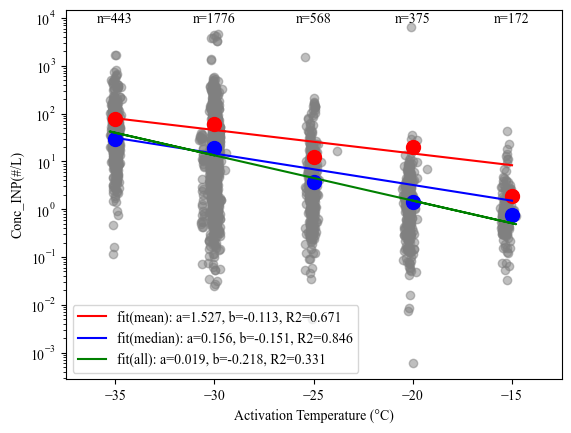

In [3]:
# 使用matplotlib绘制温度谱分布， 并用scipy拟合， 用R2评价拟合效果（AI生成）

temp_order = [-35, -30, -25, -20, -15]
# 获取平均值和中位数
mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
# 拟合
def func(T, a, b):
    return a * np.exp(b * T)
popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, bounds=([0, -np.inf], [np.inf, 0]))

x_all = df_selected['T_inp(°C)'].to_numpy(float)
y_all = df_selected['N_inp_net(#/L)'].to_numpy(float)
mask = (y_all > 0) & np.isfinite(x_all) & np.isfinite(y_all)
x = x_all[mask]
ly = np.log(y_all[mask])
# ln(y) = ln(a) + b*T
b, ln_a = np.polyfit(x, ly, 1)
a = np.exp(ln_a)
popt3 = (a, b)


# R² 的计算
def r2_log(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    mask = (y > 0) & (yhat > 0) & np.isfinite(y) & np.isfinite(yhat)
    ly = np.log(y[mask])
    lyhat = np.log(yhat[mask])

    ss_res = np.sum((ly - lyhat) ** 2)
    ss_tot = np.sum((ly - np.mean(ly)) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

x_mean = mean_inp.index.to_numpy(float)
y_mean = mean_inp.to_numpy(float)
yhat_mean = func(x_mean, *popt1)
r2_mean = r2_log(y_mean, yhat_mean)

x_med = median_inp.index.to_numpy(float)
y_med = median_inp.to_numpy(float)
yhat_med = func(x_med, *popt2)
r2_med = r2_log(y_med, yhat_med)

yhat_all = func(x_all, *popt3)
r2_all = r2_log(y_all, yhat_all)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(df_selected['T_inp(°C)'], df_selected['N_inp_net(#/L)'], alpha=0.5, c='grey')
ax.scatter(mean_inp.index, mean_inp.values, color='red', s=100)
ax.scatter(median_inp.index, median_inp.values, color='blue', s=100)
ax.plot(x_mean, yhat_mean, 'r-',
        label='fit(mean): a=%5.3f, b=%5.3f, R2=%.3f' % (*popt1, r2_mean))
ax.plot(x_med, yhat_med, 'b-',
        label='fit(median): a=%5.3f, b=%5.3f, R2=%.3f' % (*popt2, r2_med))
ax.plot(x_all, yhat_all, 'g-',
        label='fit(all): a=%5.3f, b=%5.3f, R2=%.3f' % (*popt3, r2_all))
for temp in temp_order:
    count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
    ax.text(temp, ax.get_ylim()[1] * 1, f'n={count}', ha='center', va='bottom')

ax.set_xlim(-37.5, -12.5)
ax.set_yscale('log')
ax.set_xlabel('Activation Temperature (°C)')
ax.set_ylabel('Conc_INP(#/L)')
ax.legend(loc='lower left')

## 分季节数据

总点数量: 4371
Spring有效点数量: 1127
总点数量: 4371
Summer有效点数量: 319
总点数量: 4371
Autumn有效点数量: 875
总点数量: 4371
Winter有效点数量: 1013


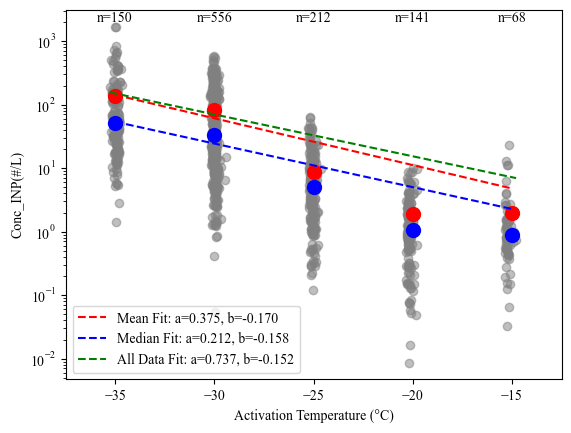

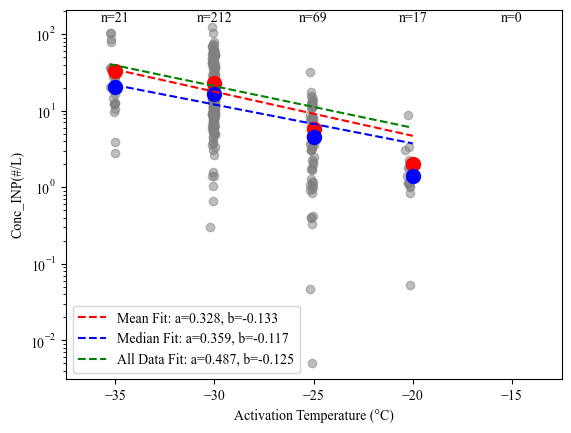

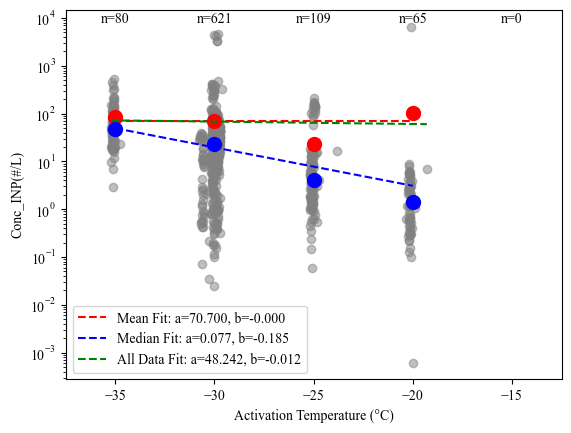

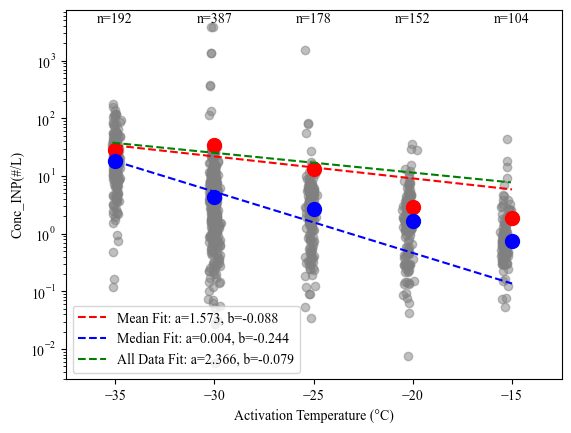

In [ ]:
# 不同季节的INP温度谱分布
## 质量控制
for season in ['Spring', 'Summer', 'Autumn', 'Winter']:
    df_selected = df[df['N_inp_net(#/L)'] > 0]
    df_selected = df_selected[df_selected['season'] == season]
    #df_selected = df_selected[df_selected['SS_w'] > 0]
    print(f"总点数量: {df.shape[0]}")
    print(f"{season}有效点数量: {df_selected.shape[0]}")

    temp_order = [-35, -30, -25, -20, -15]
    # 获取平均值和中位数
    mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
    median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
    # 拟合
    def func(T, a, b):
        return a * np.exp(b * T)
    popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
    popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
    popt3, pcov3 = curve_fit(func, df_selected['T_inp(°C)'], df_selected['N_inp_net(#/L)'], bounds=([0, -np.inf], [np.inf, 0]))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.scatter(df_selected['T_inp(°C)'], df_selected['N_inp_net(#/L)'], alpha=0.5, c='grey')
    ax.scatter(mean_inp.index, mean_inp.values, color='red', s=100)
    ax.scatter(median_inp.index, median_inp.values, color='blue', s=100)
    ax.plot(mean_inp.index, func(mean_inp.index, *popt1), 'r--',
            label='Mean Fit: a=%5.3f, b=%5.3f' % tuple(popt1))
    ax.plot(median_inp.index, func(median_inp.index, *popt2), 'b--',
            label='Median Fit: a=%5.3f, b=%5.3f' % tuple(popt2))
    ax.plot(np.sort(df_selected['T_inp(°C)']),
            func(np.sort(df_selected['T_inp(°C)']), *popt3), 'g--',
            label='All Data Fit: a=%5.3f, b=%5.3f' % tuple(popt3))
    for temp in temp_order:
        count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
        ax.text(temp, ax.get_ylim()[1] * 1, f'n={count}', ha='center', va='bottom')

    ax.set_xlim(-37.5, -12.5)
    ax.set_yscale('log')
    ax.set_xlabel('Activation Temperature (°C)')
    ax.set_ylabel('Conc_INP(#/L)')
    ax.legend(loc='lower left')

Spring总点数量: 1366
Spring有效点数量: 1127
Summer总点数量: 369
Summer有效点数量: 319
Autumn总点数量: 1070
Autumn有效点数量: 875
Winter总点数量: 1566
Winter有效点数量: 1013


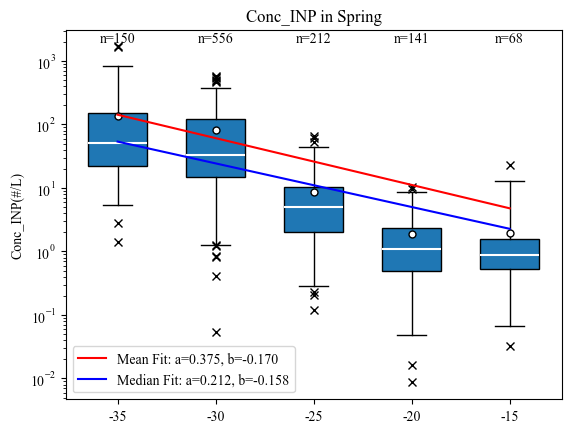

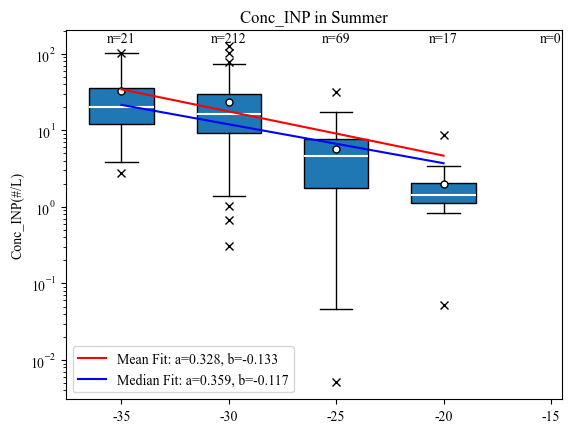

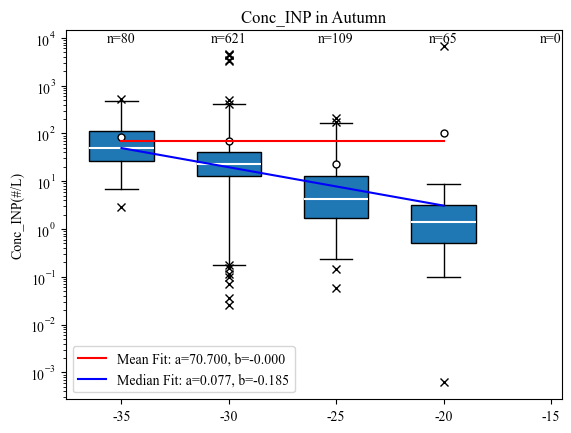

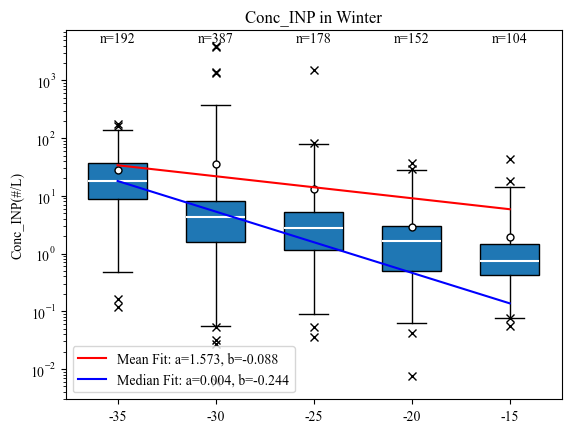

In [4]:
# 使用 matplotlib 绘制并拟合各个季节的温度谱分布
for i, season in enumerate(['Spring', 'Summer', 'Autumn', 'Winter']):
    df_selected = df[df['season'] == season]
    print(f"{season}总点数量: {df_selected.shape[0]}")
    df_selected = df_selected[df_selected['N_inp_net(#/L)'] > 0]
    print(f"{season}有效点数量: {df_selected.shape[0]}")
    
    def func(T, a, b):
        return a * np.exp(b * T)
    
    mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
    popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, 
                             bounds=([0, -np.inf], [np.inf, 0])
                             )
    median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
    popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, 
                             bounds=([0, -np.inf], [np.inf, 0])
                             )
    
    temp_order = [-35, -30, -25, -20, -15]
    data_for_box = [df_selected[df_selected['T_a(°C)'] == t]['N_inp_net(#/L)'] for t in temp_order]
    

    fig = plt.figure()
    ax = fig.add_subplot(111)
    box = ax.boxplot(
        data_for_box,
        tick_labels=temp_order,
        showmeans=True,
        meanprops={"marker": "o",
                   "markerfacecolor": "white",
                   "markeredgecolor": "black",
                   "markersize": 5},
        flierprops={"marker": "x"},
        medianprops={'color': 'white', 'linewidth': 1.5},
        patch_artist=True,
        positions=temp_order,
        widths=3,
        whis=[1, 99]
    )
    
    x1 = mean_inp.index
    x2 = median_inp.index
    y1 = func(mean_inp.index, *popt1)
    y2 = func(median_inp.index, *popt2)

    ax.plot(x1, y1, 'r-', zorder=10,
            label='Mean Fit: a=%5.3f, b=%5.3f' % tuple(popt1))
    ax.plot(x2, y2, 'b-', zorder=10,
            label='Median Fit: a=%5.3f, b=%5.3f' % tuple(popt2))
    
    for temp in temp_order:
        count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
        ax.text(temp, ax.get_ylim()[1] * 1, f'n={count}', ha='center', va='bottom')
    ax.set_yscale('log')
    ax.set_ylabel('Conc_INP(#/L)')
    ax.set_title(f'Conc_INP in {season}')
    ax.legend(loc='lower left')
    fig.subplots_adjust(hspace=0.4)

Spring总点数量: 1366
Spring有效点数量: 1127
Summer总点数量: 369
Summer有效点数量: 319
Autumn总点数量: 1070
Autumn有效点数量: 875
Winter总点数量: 1566
Winter有效点数量: 1013


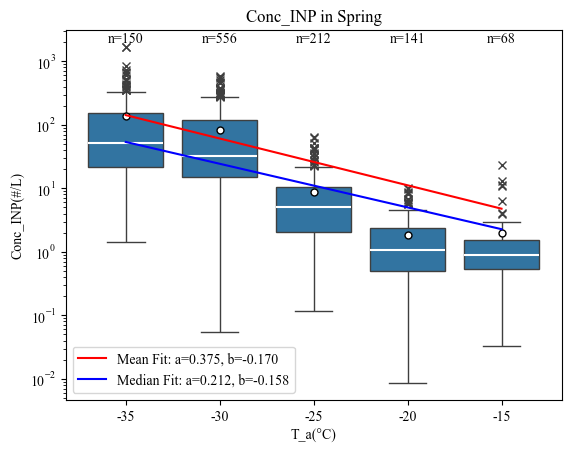

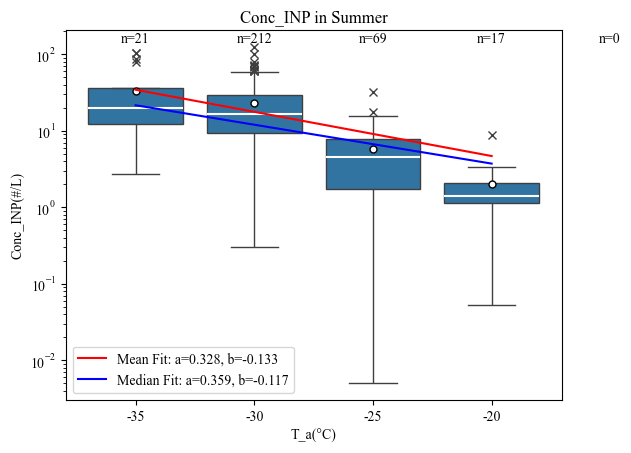

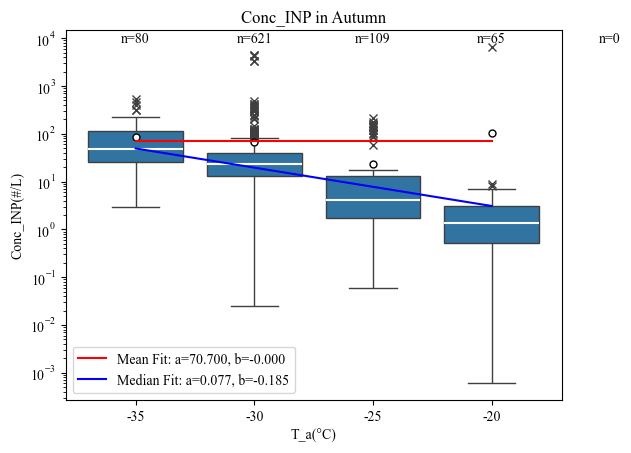

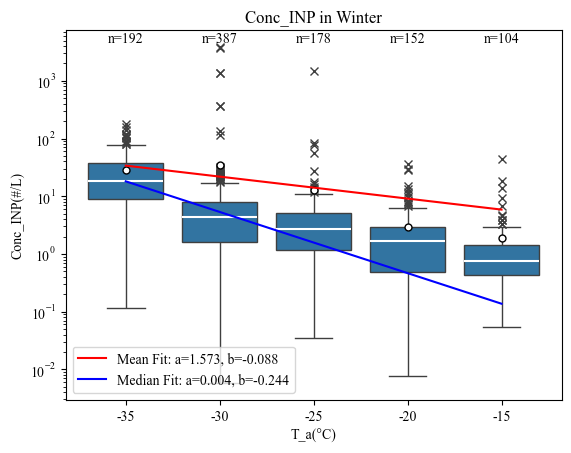

In [5]:
# 使用 seaborn 绘制并拟合各个季节的温度谱分布
for season in ['Spring', 'Summer', 'Autumn', 'Winter']:
    df_selected = df[df['season']==season]
    print(f"{season}总点数量: {df_selected.shape[0]}")
    df_selected = df_selected[df_selected['N_inp_net(#/L)'] > 0]
    print(f"{season}有效点数量: {df_selected.shape[0]}")
    
    def func(T, a, b):
        return a * np.exp(b * T)
    mean_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].mean()
    popt1, pcov1 = curve_fit(func, mean_inp.index, mean_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
    median_inp = df_selected.groupby('T_a(°C)')['N_inp_net(#/L)'].median()
    popt2, pcov2 = curve_fit(func, median_inp.index, median_inp.values, bounds=([0, -np.inf], [np.inf, 0]))
    
    temp_order = [-35, -30, -25, -20, -15]
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    sns.boxplot(data=df_selected, x='T_a(°C)', y='N_inp_net(#/L)',
                order=temp_order,
                ax=ax,
                showmeans=True,
                meanprops={"marker":"o",
                        "markerfacecolor":"white",
                        "markeredgecolor":"black",
                        "markersize":"5"},
                flierprops={"marker": "x"},
                medianprops={'color':'white', 'linewidth':1.5}
                    )
    
    x_pos = np.arange(len(temp_order))          # 0..4（分类位置）
    temp_pos = {t: i for i, t in enumerate(temp_order)}
    mean_pos = [temp_pos[t] for t in mean_inp.index if t in temp_pos]
    median_pos = [temp_pos[t] for t in median_inp.index if t in temp_pos]

    y1 = func(mean_inp.index, *popt1)
    y2 = func(median_inp.index, *popt2)
    ax.plot(mean_pos, y1, 'r-', zorder=10,
            label='Mean Fit: a=%5.3f, b=%5.3f' % tuple(popt1))
    ax.plot(median_pos, y2, 'b-', zorder=10,
            label='Median Fit: a=%5.3f, b=%5.3f' % tuple(popt2))
    for j, temp in enumerate(temp_order):
        count = df_selected[df_selected['T_a(°C)'] == temp].shape[0]
        ax.text(j, ax.get_ylim()[1]*1, f'n={count}', ha='center', va='bottom')
    ax.set_yscale('log')
    ax.set_ylabel('Conc_INP(#/L)')
    ax.set_title(f'Conc_INP in {season}')
    ax.legend(loc='lower left')

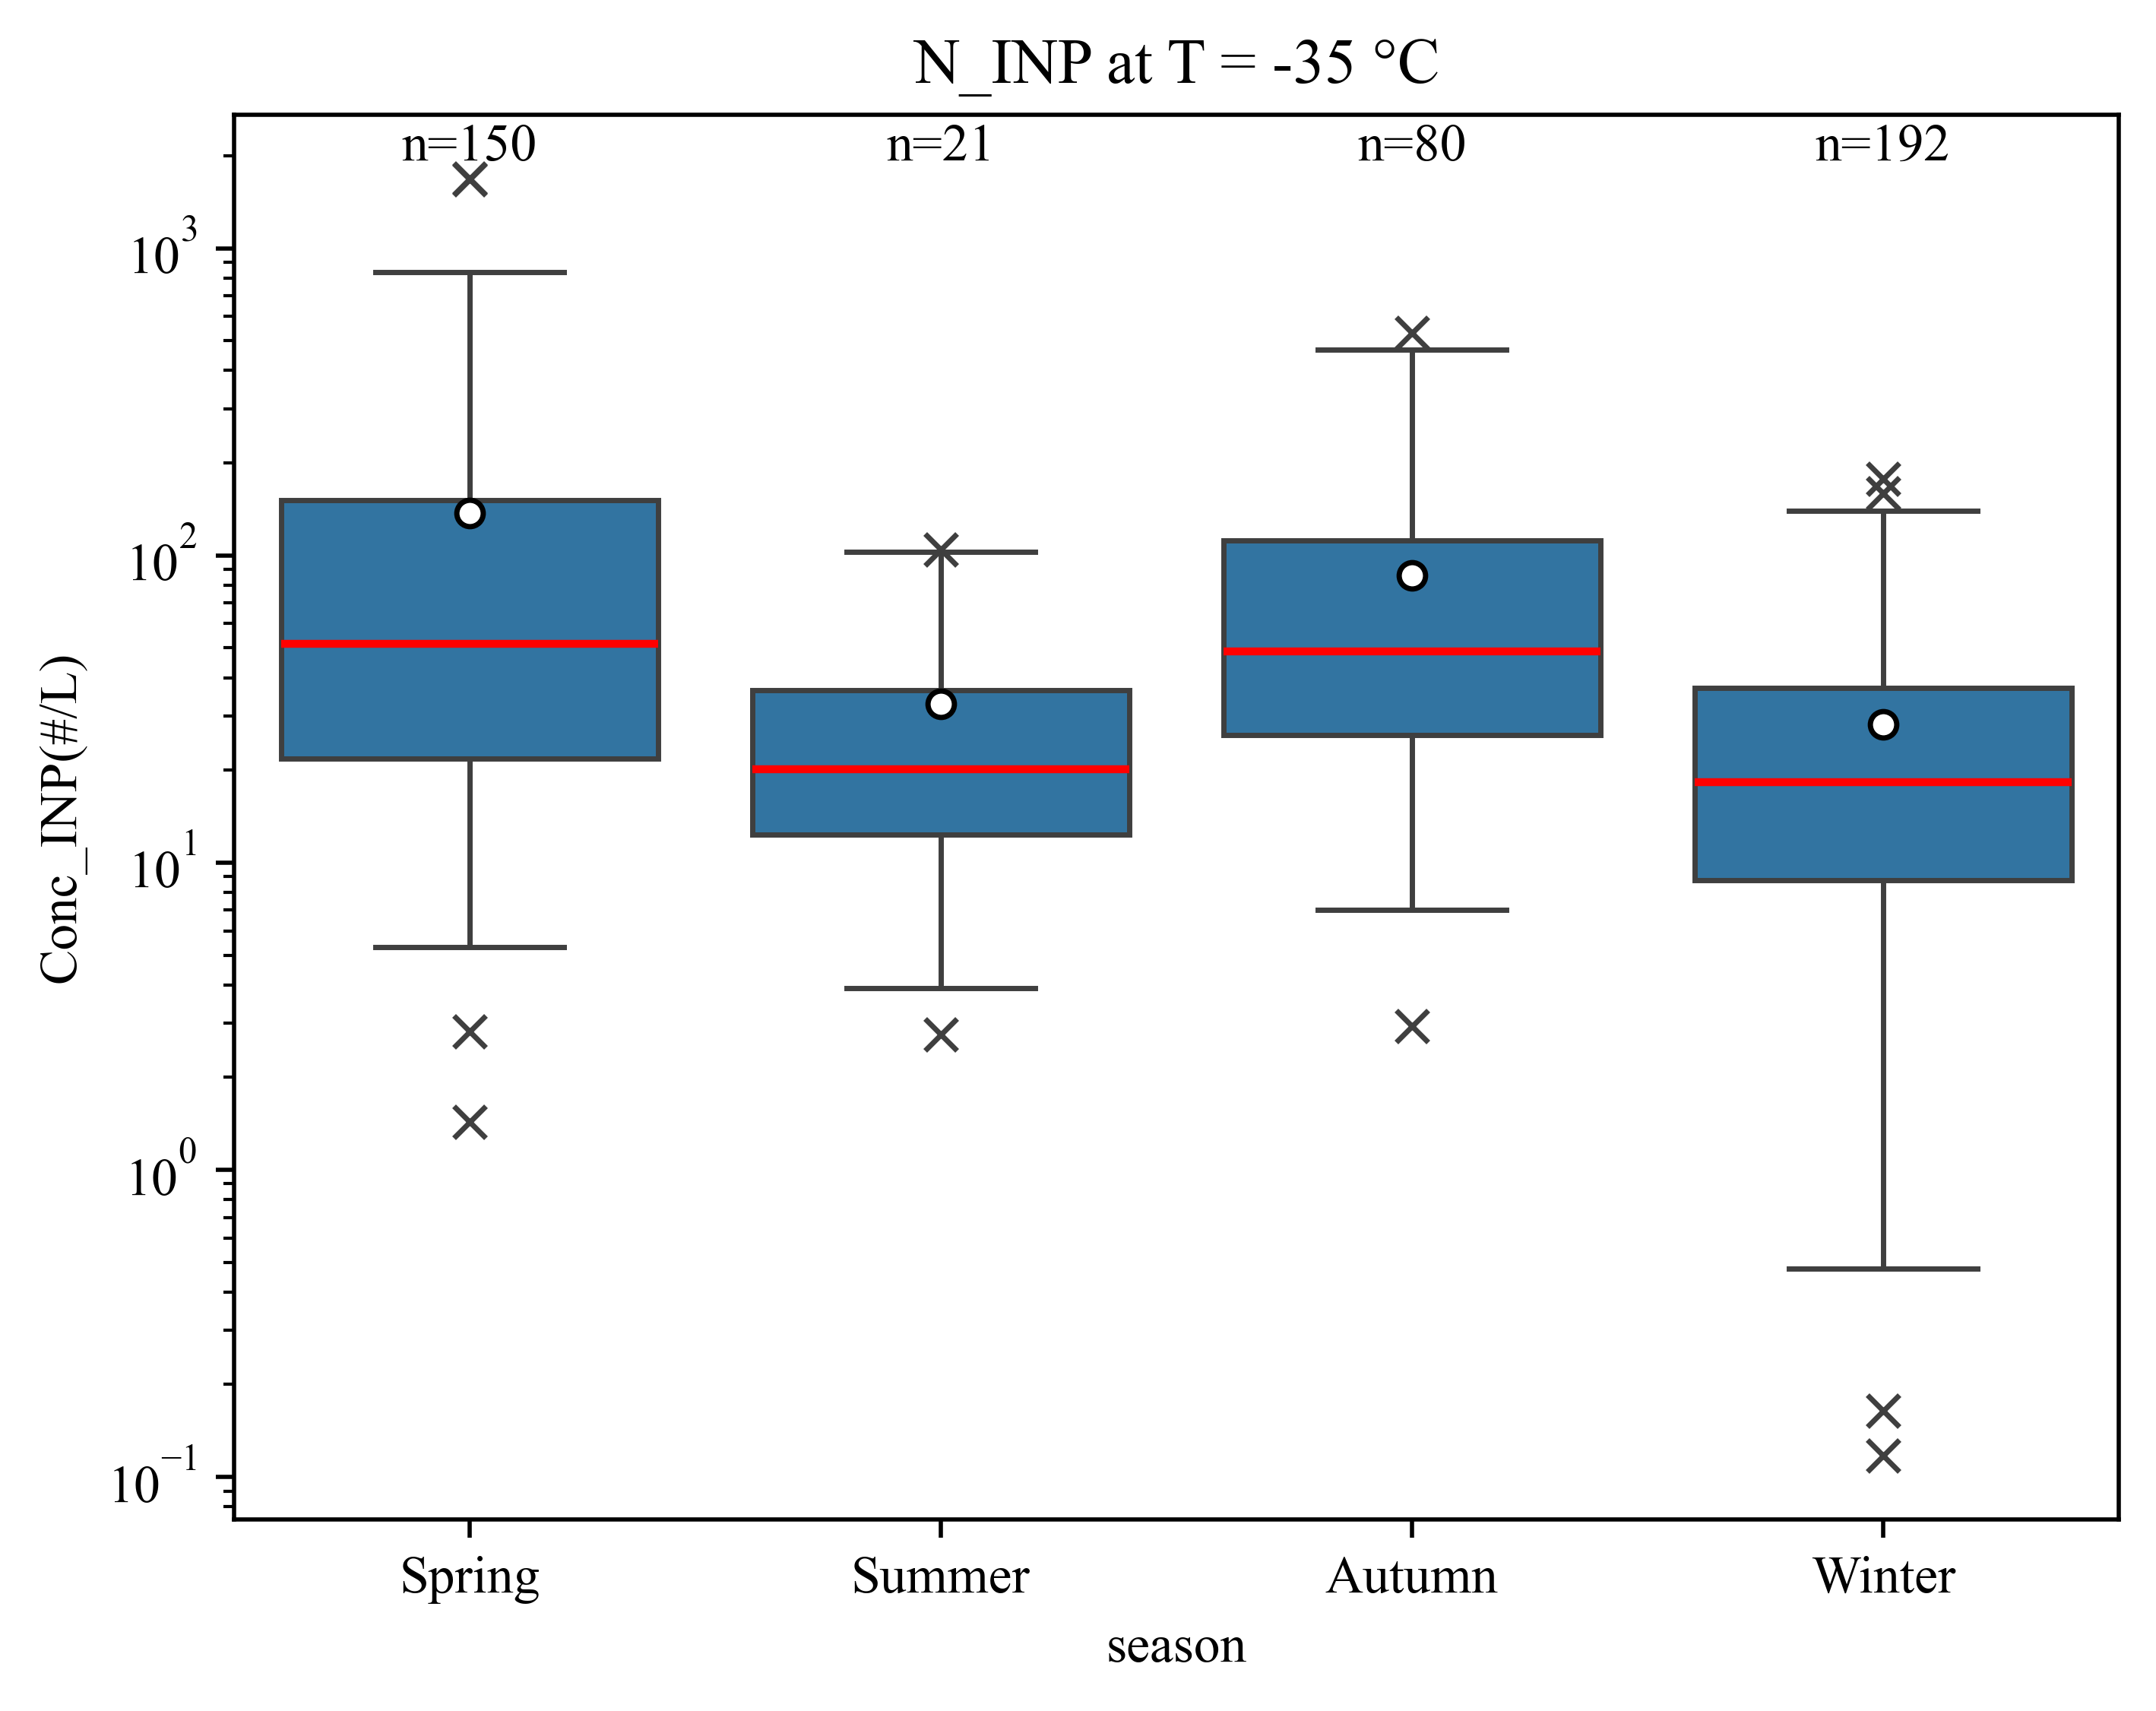

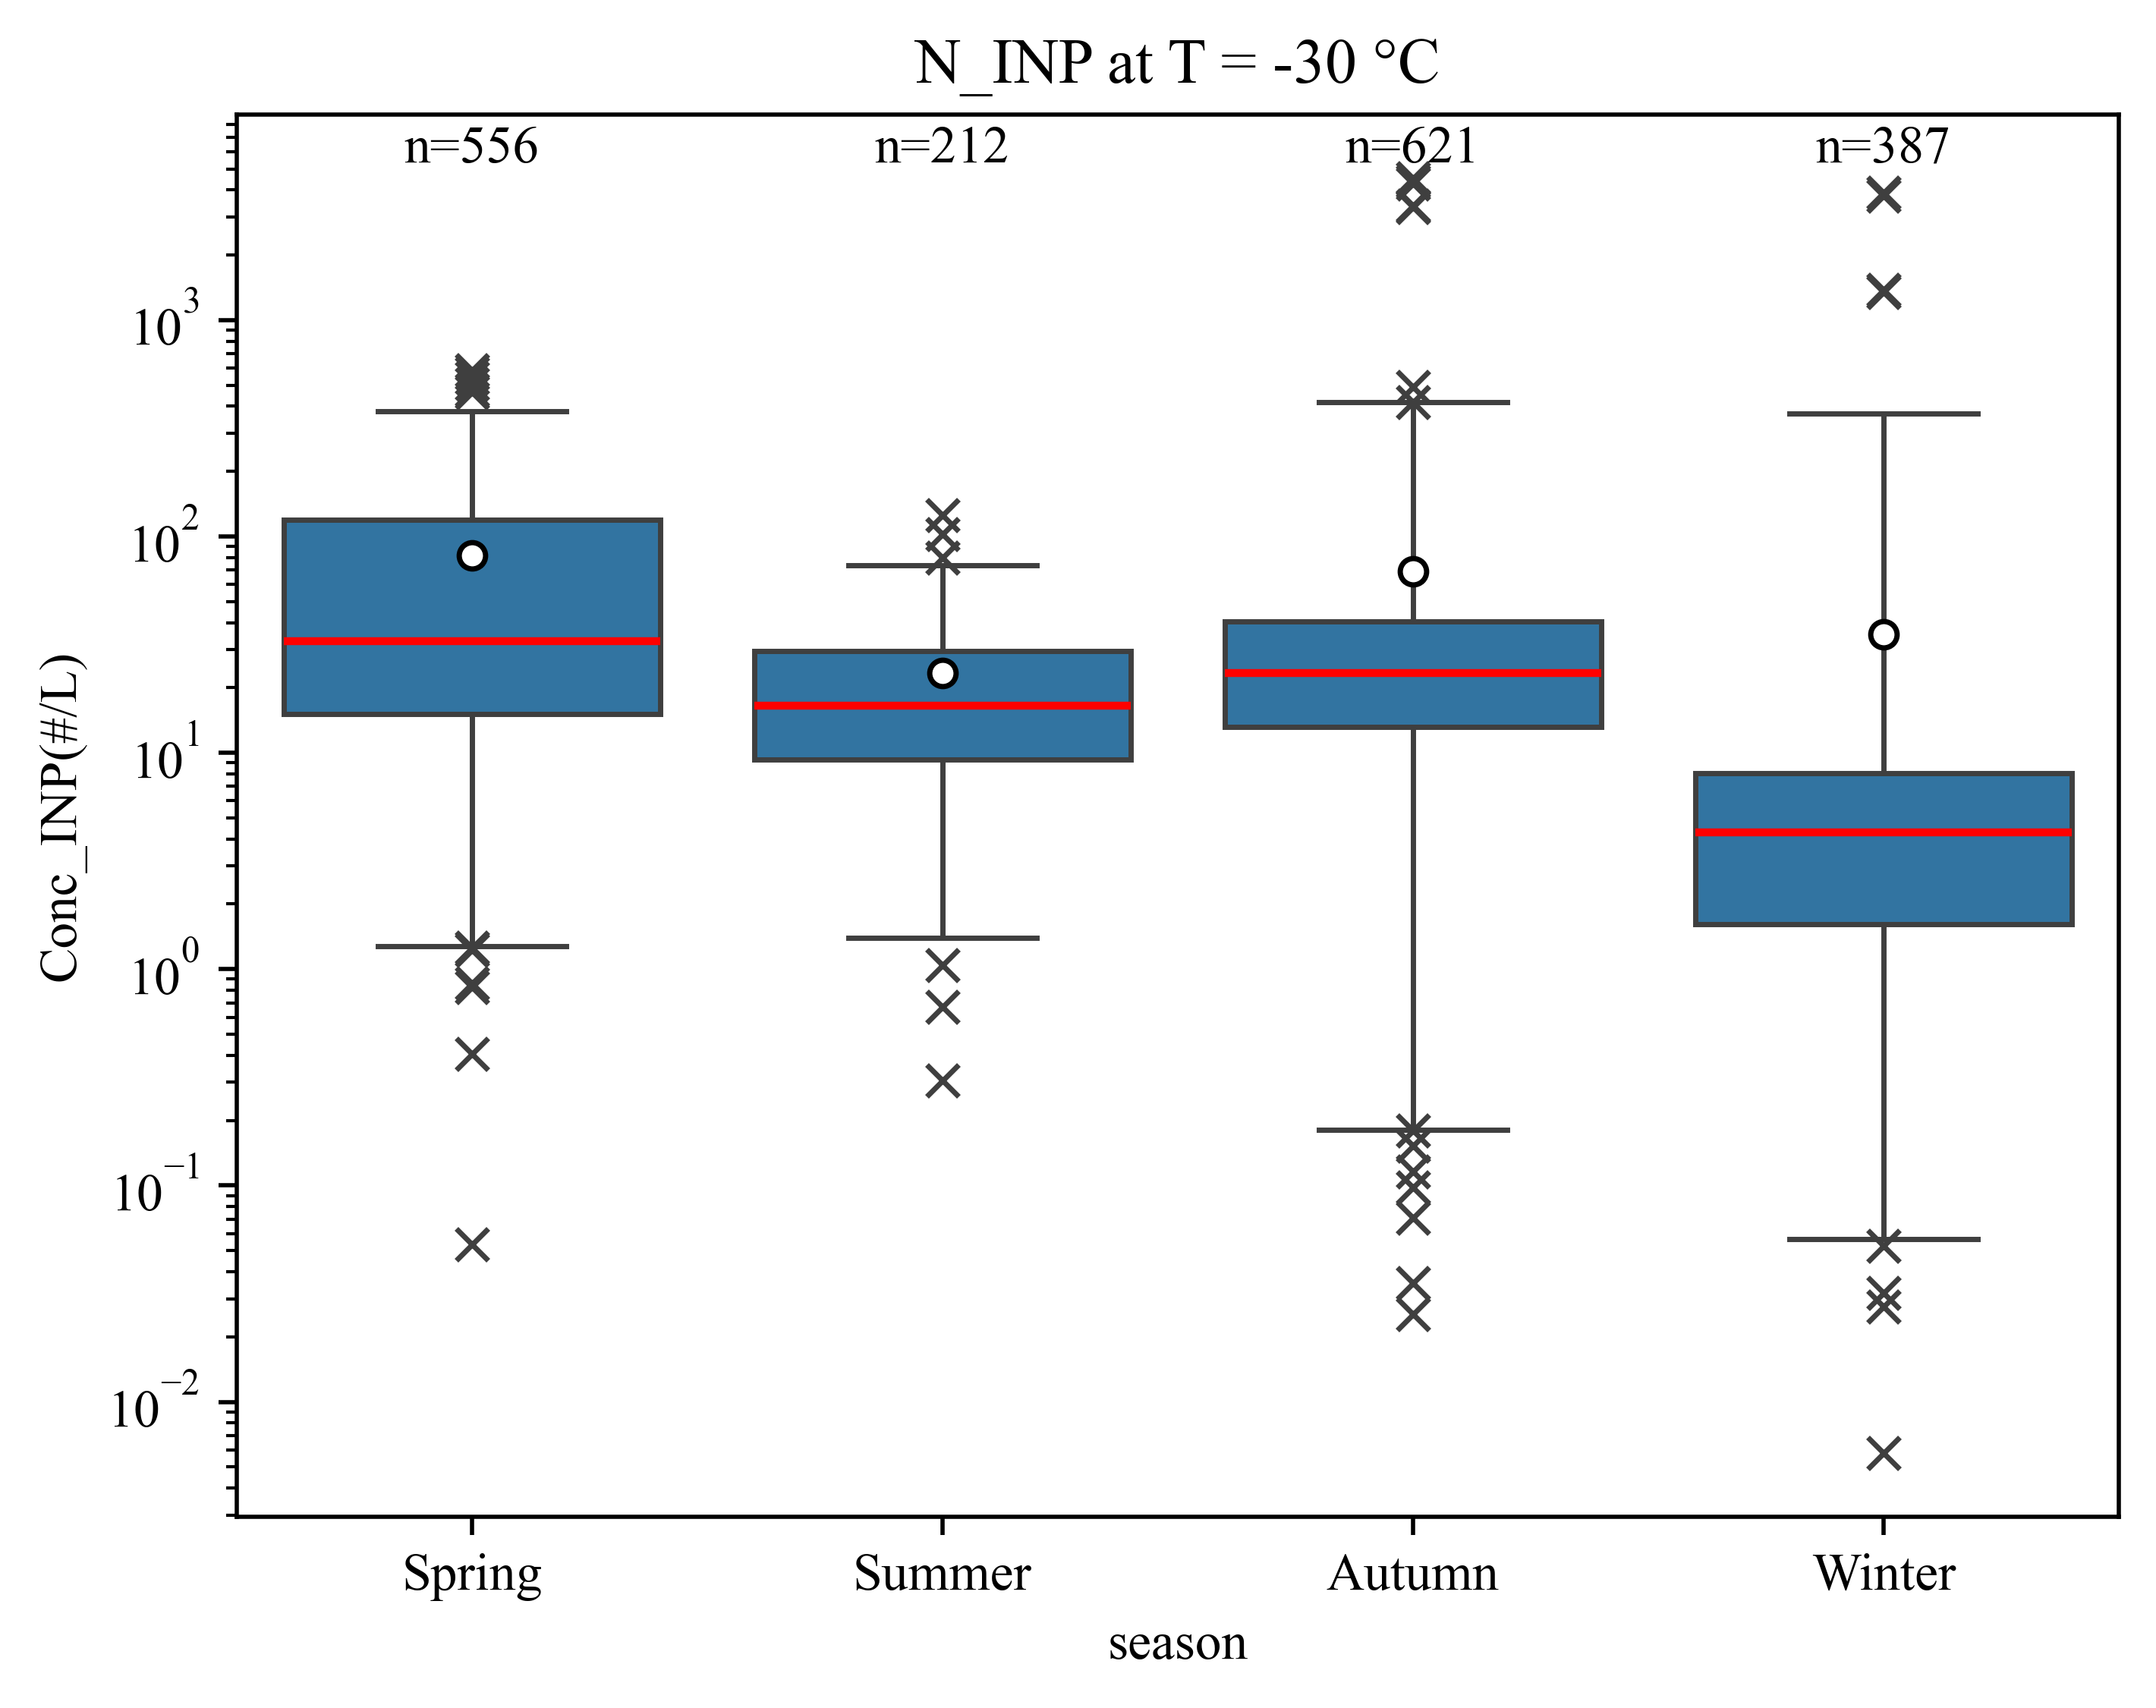

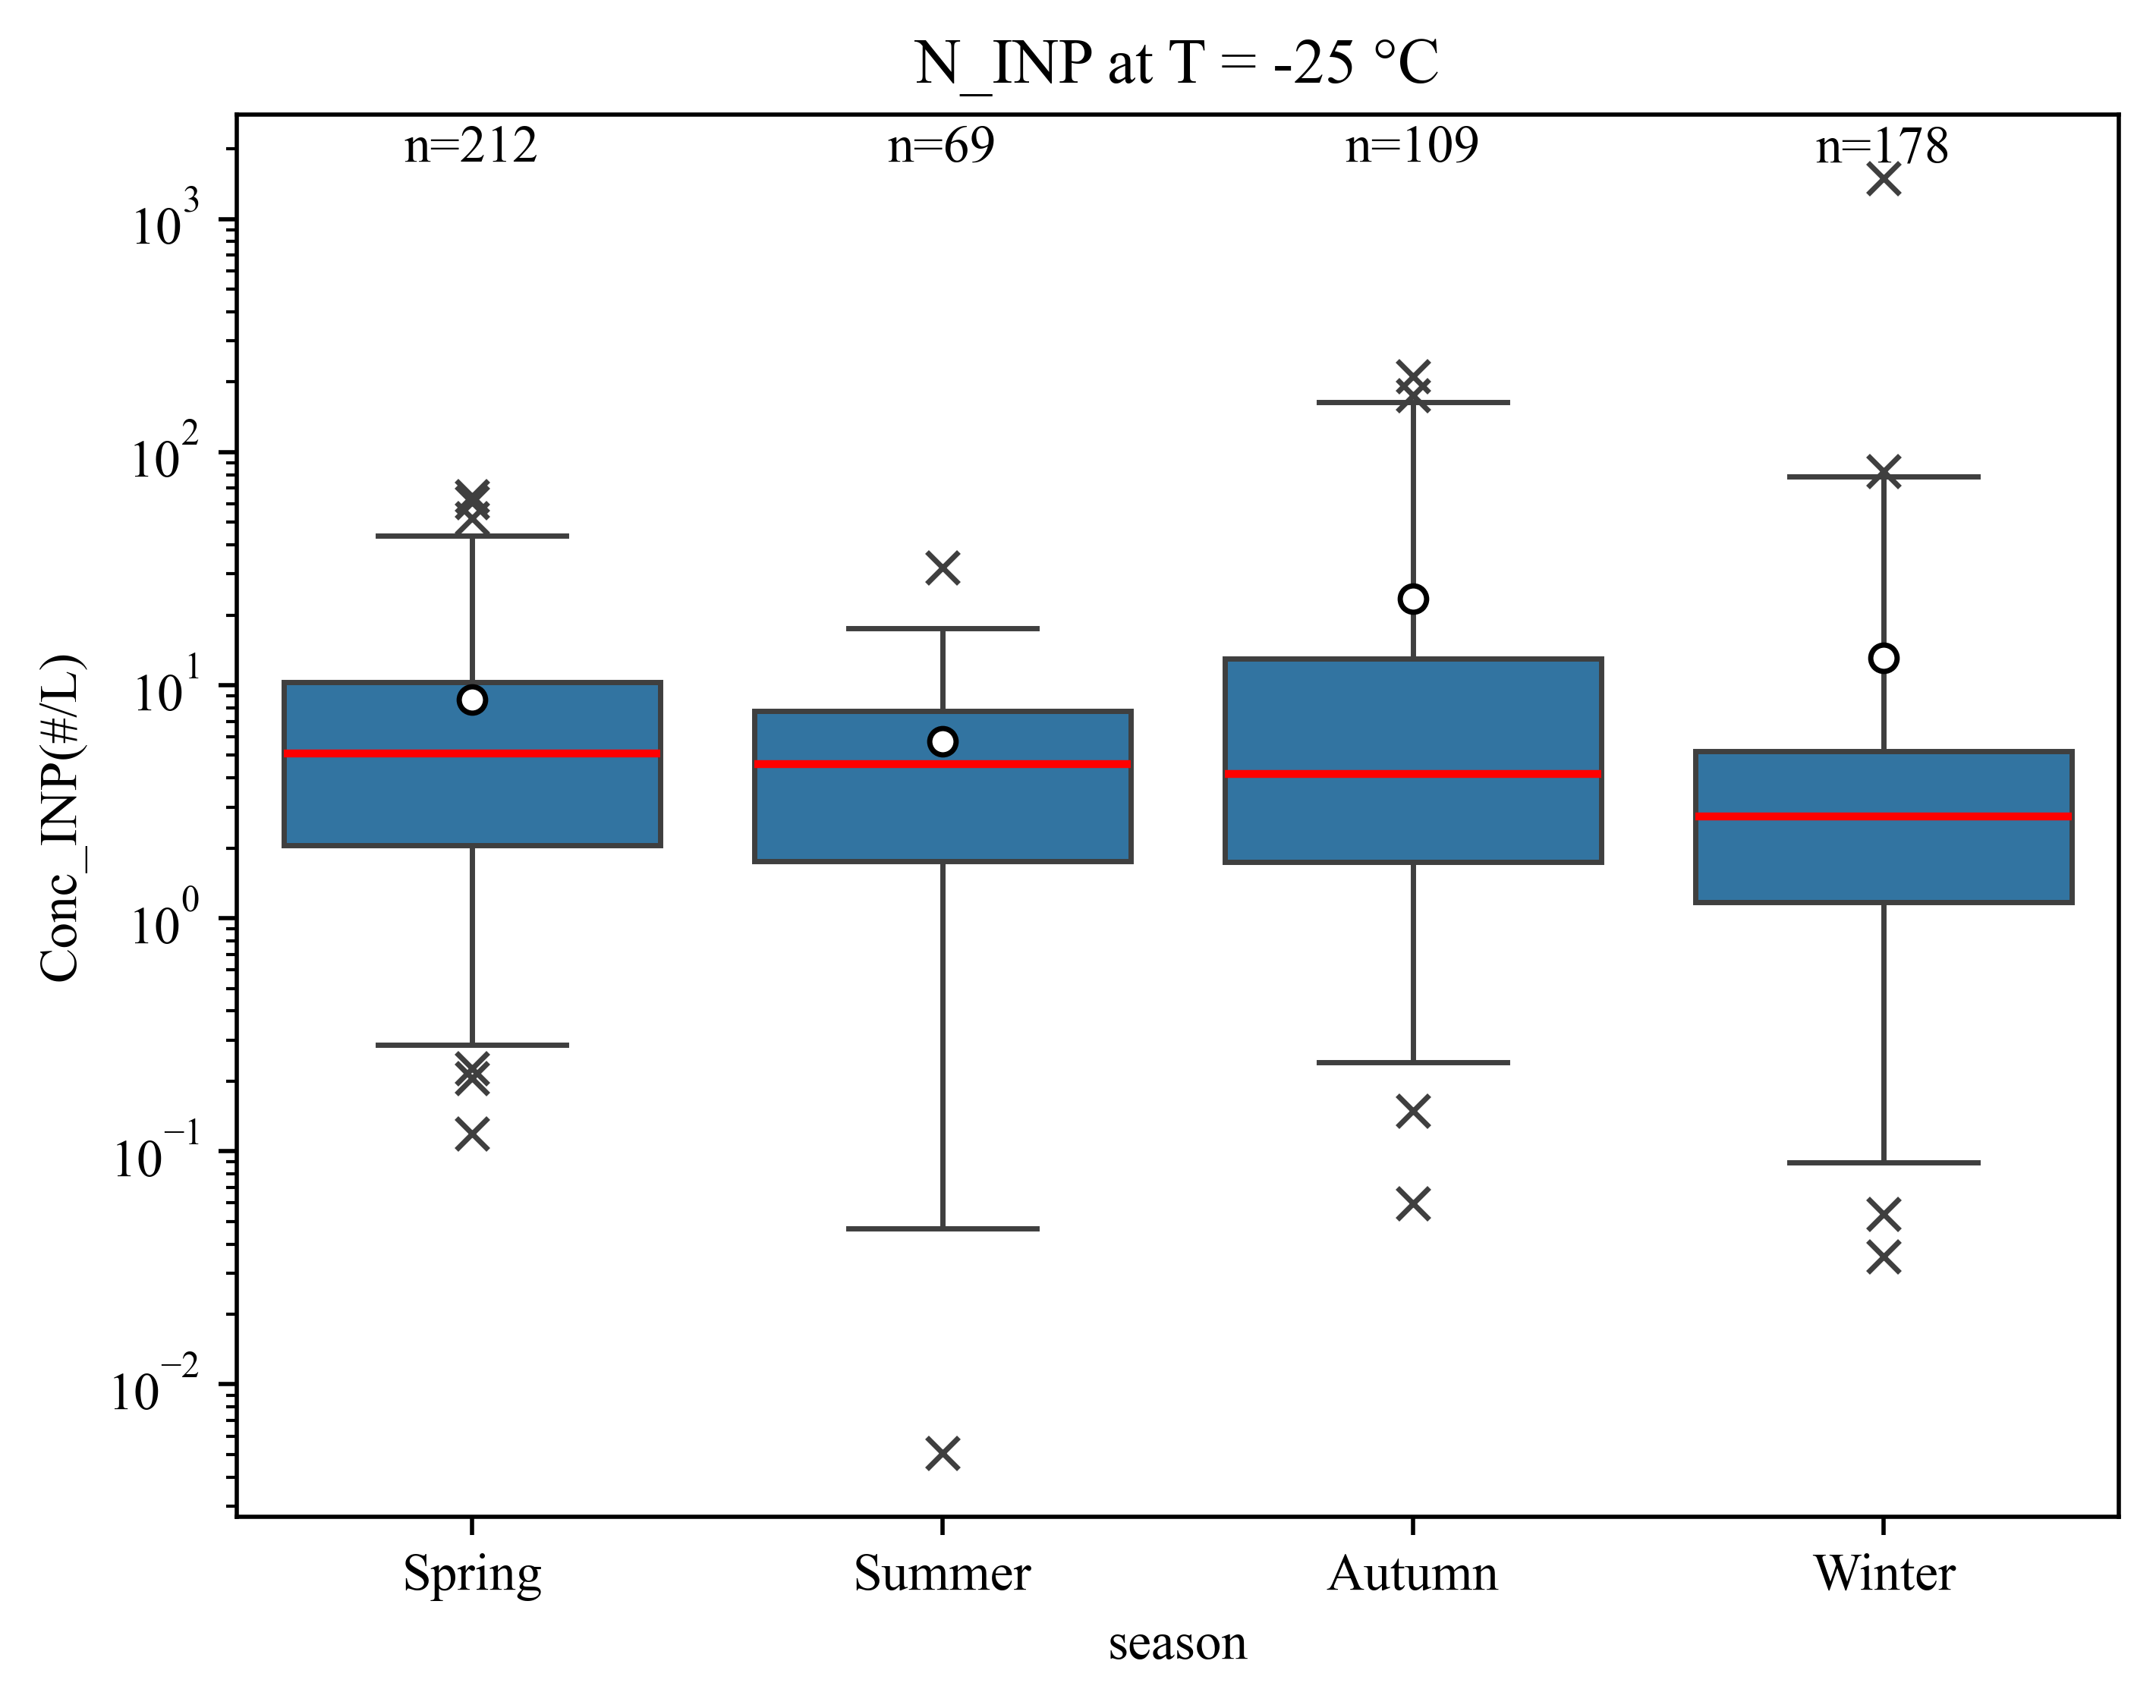

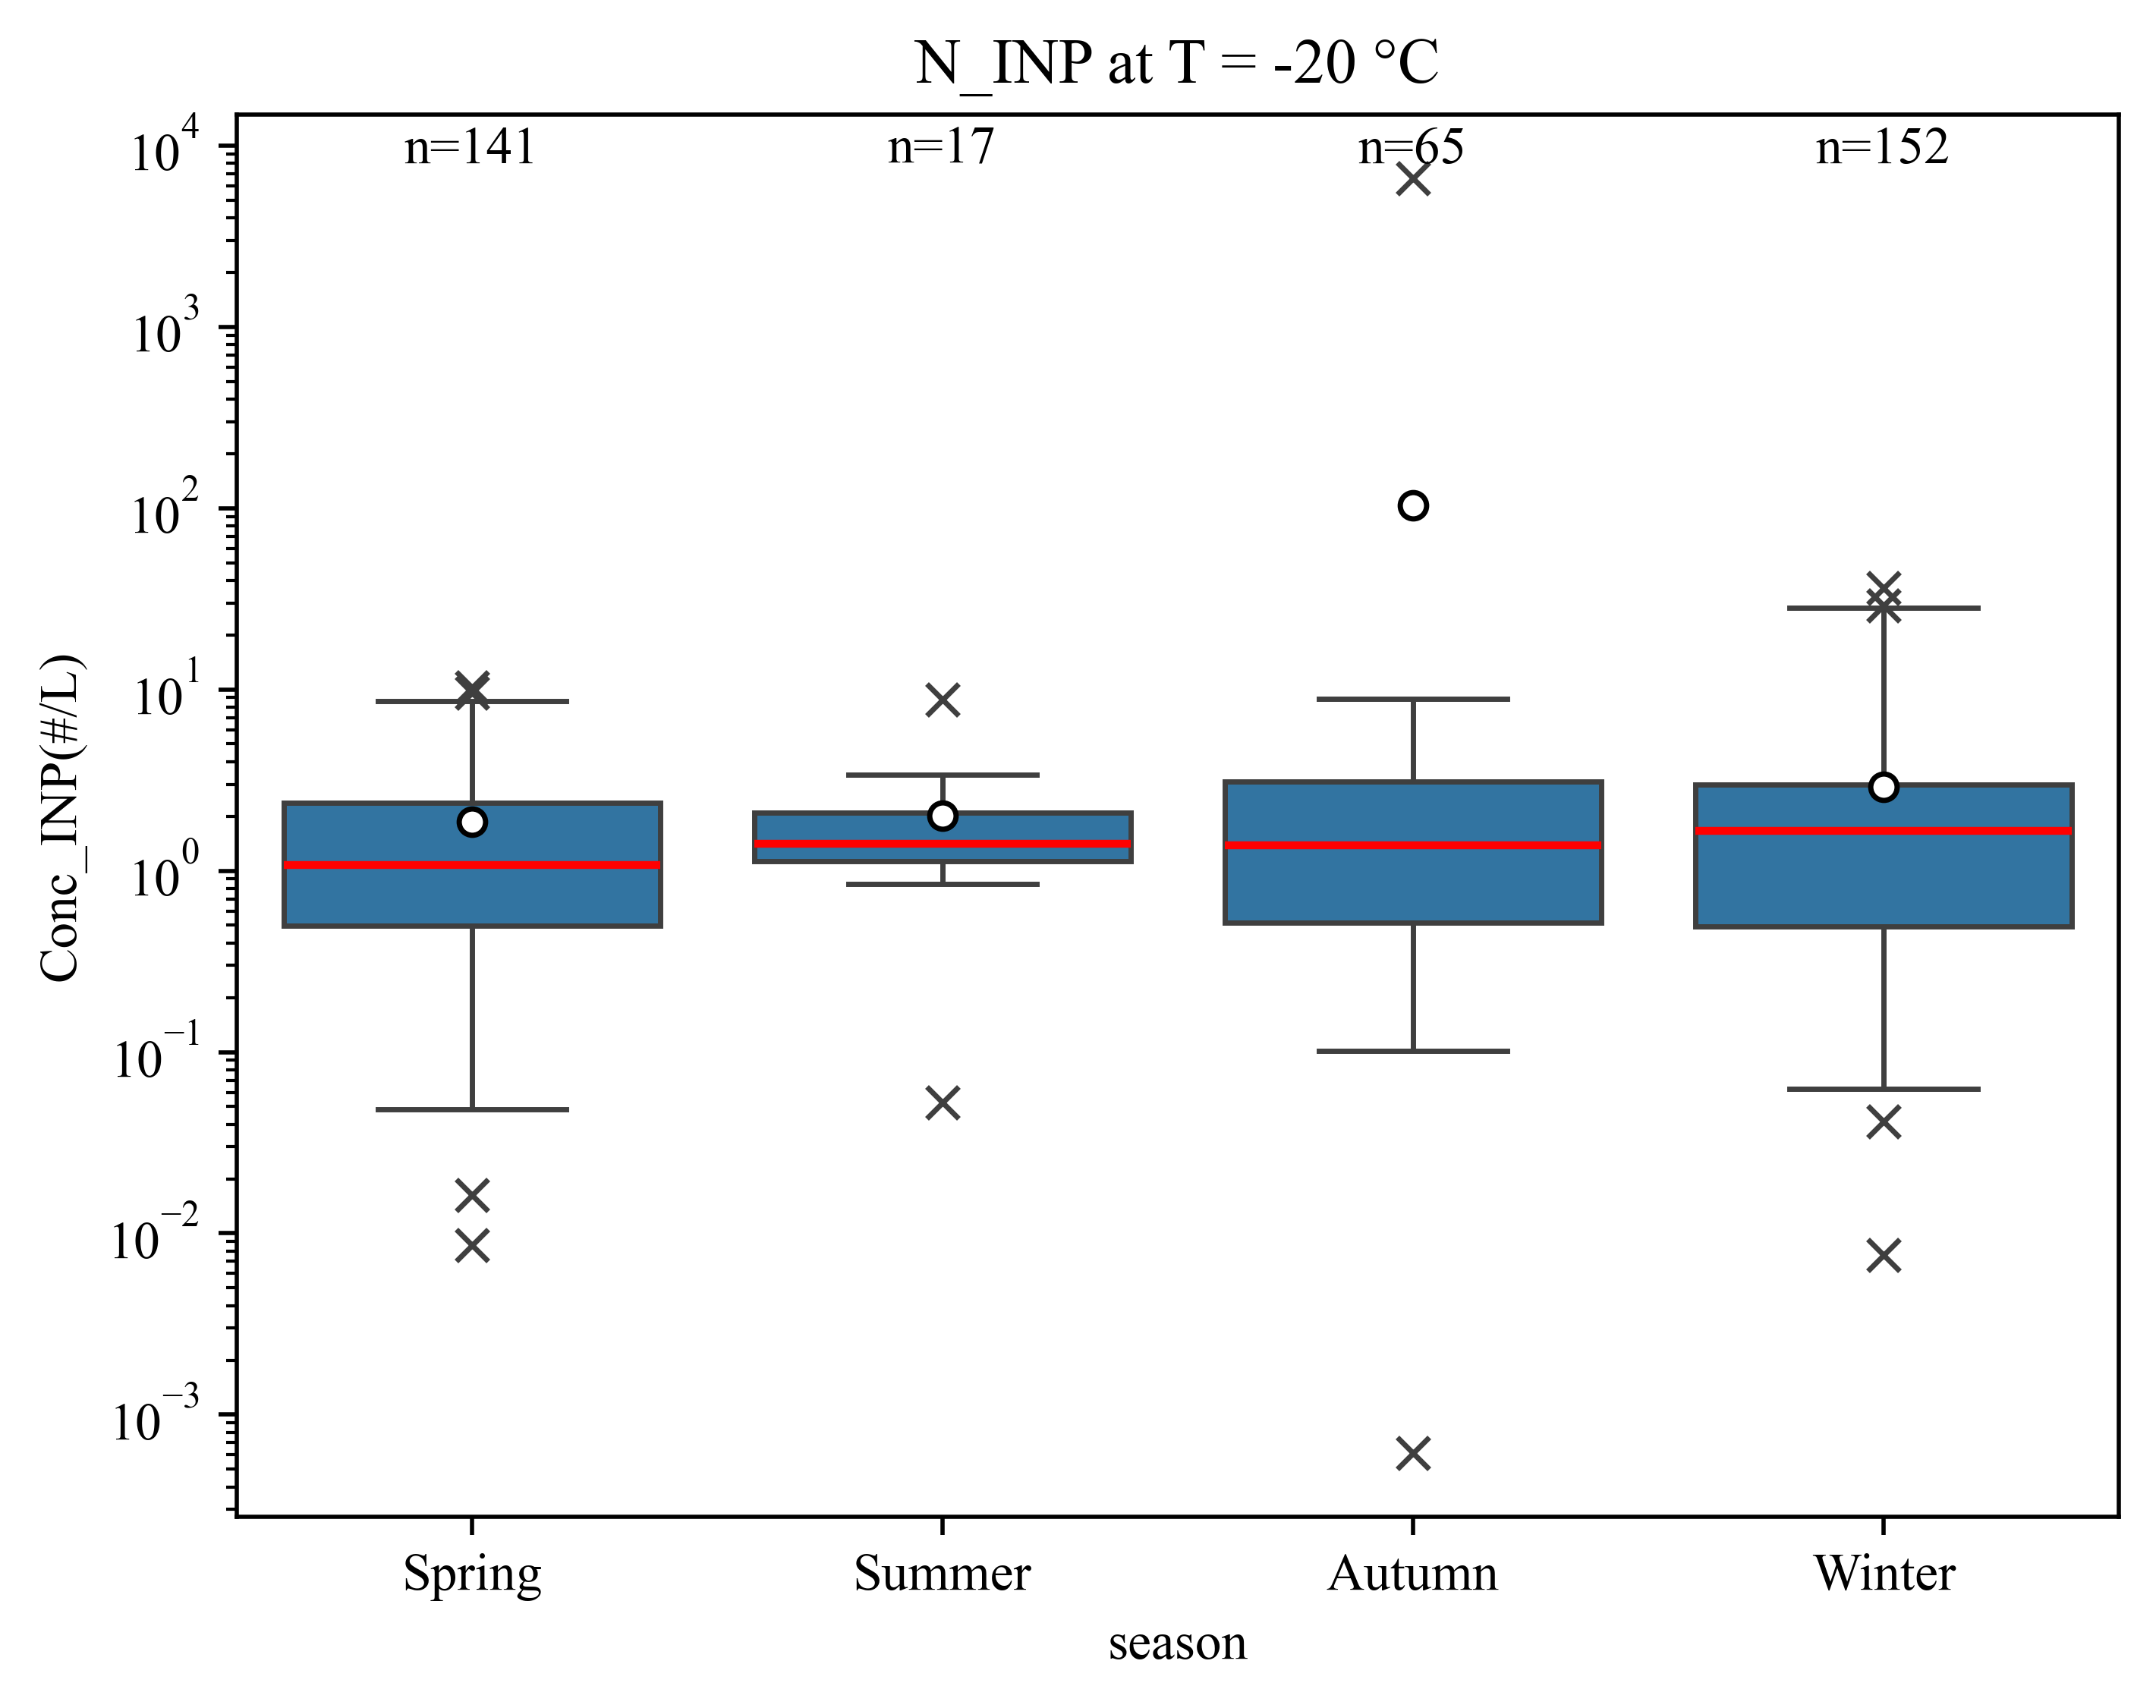

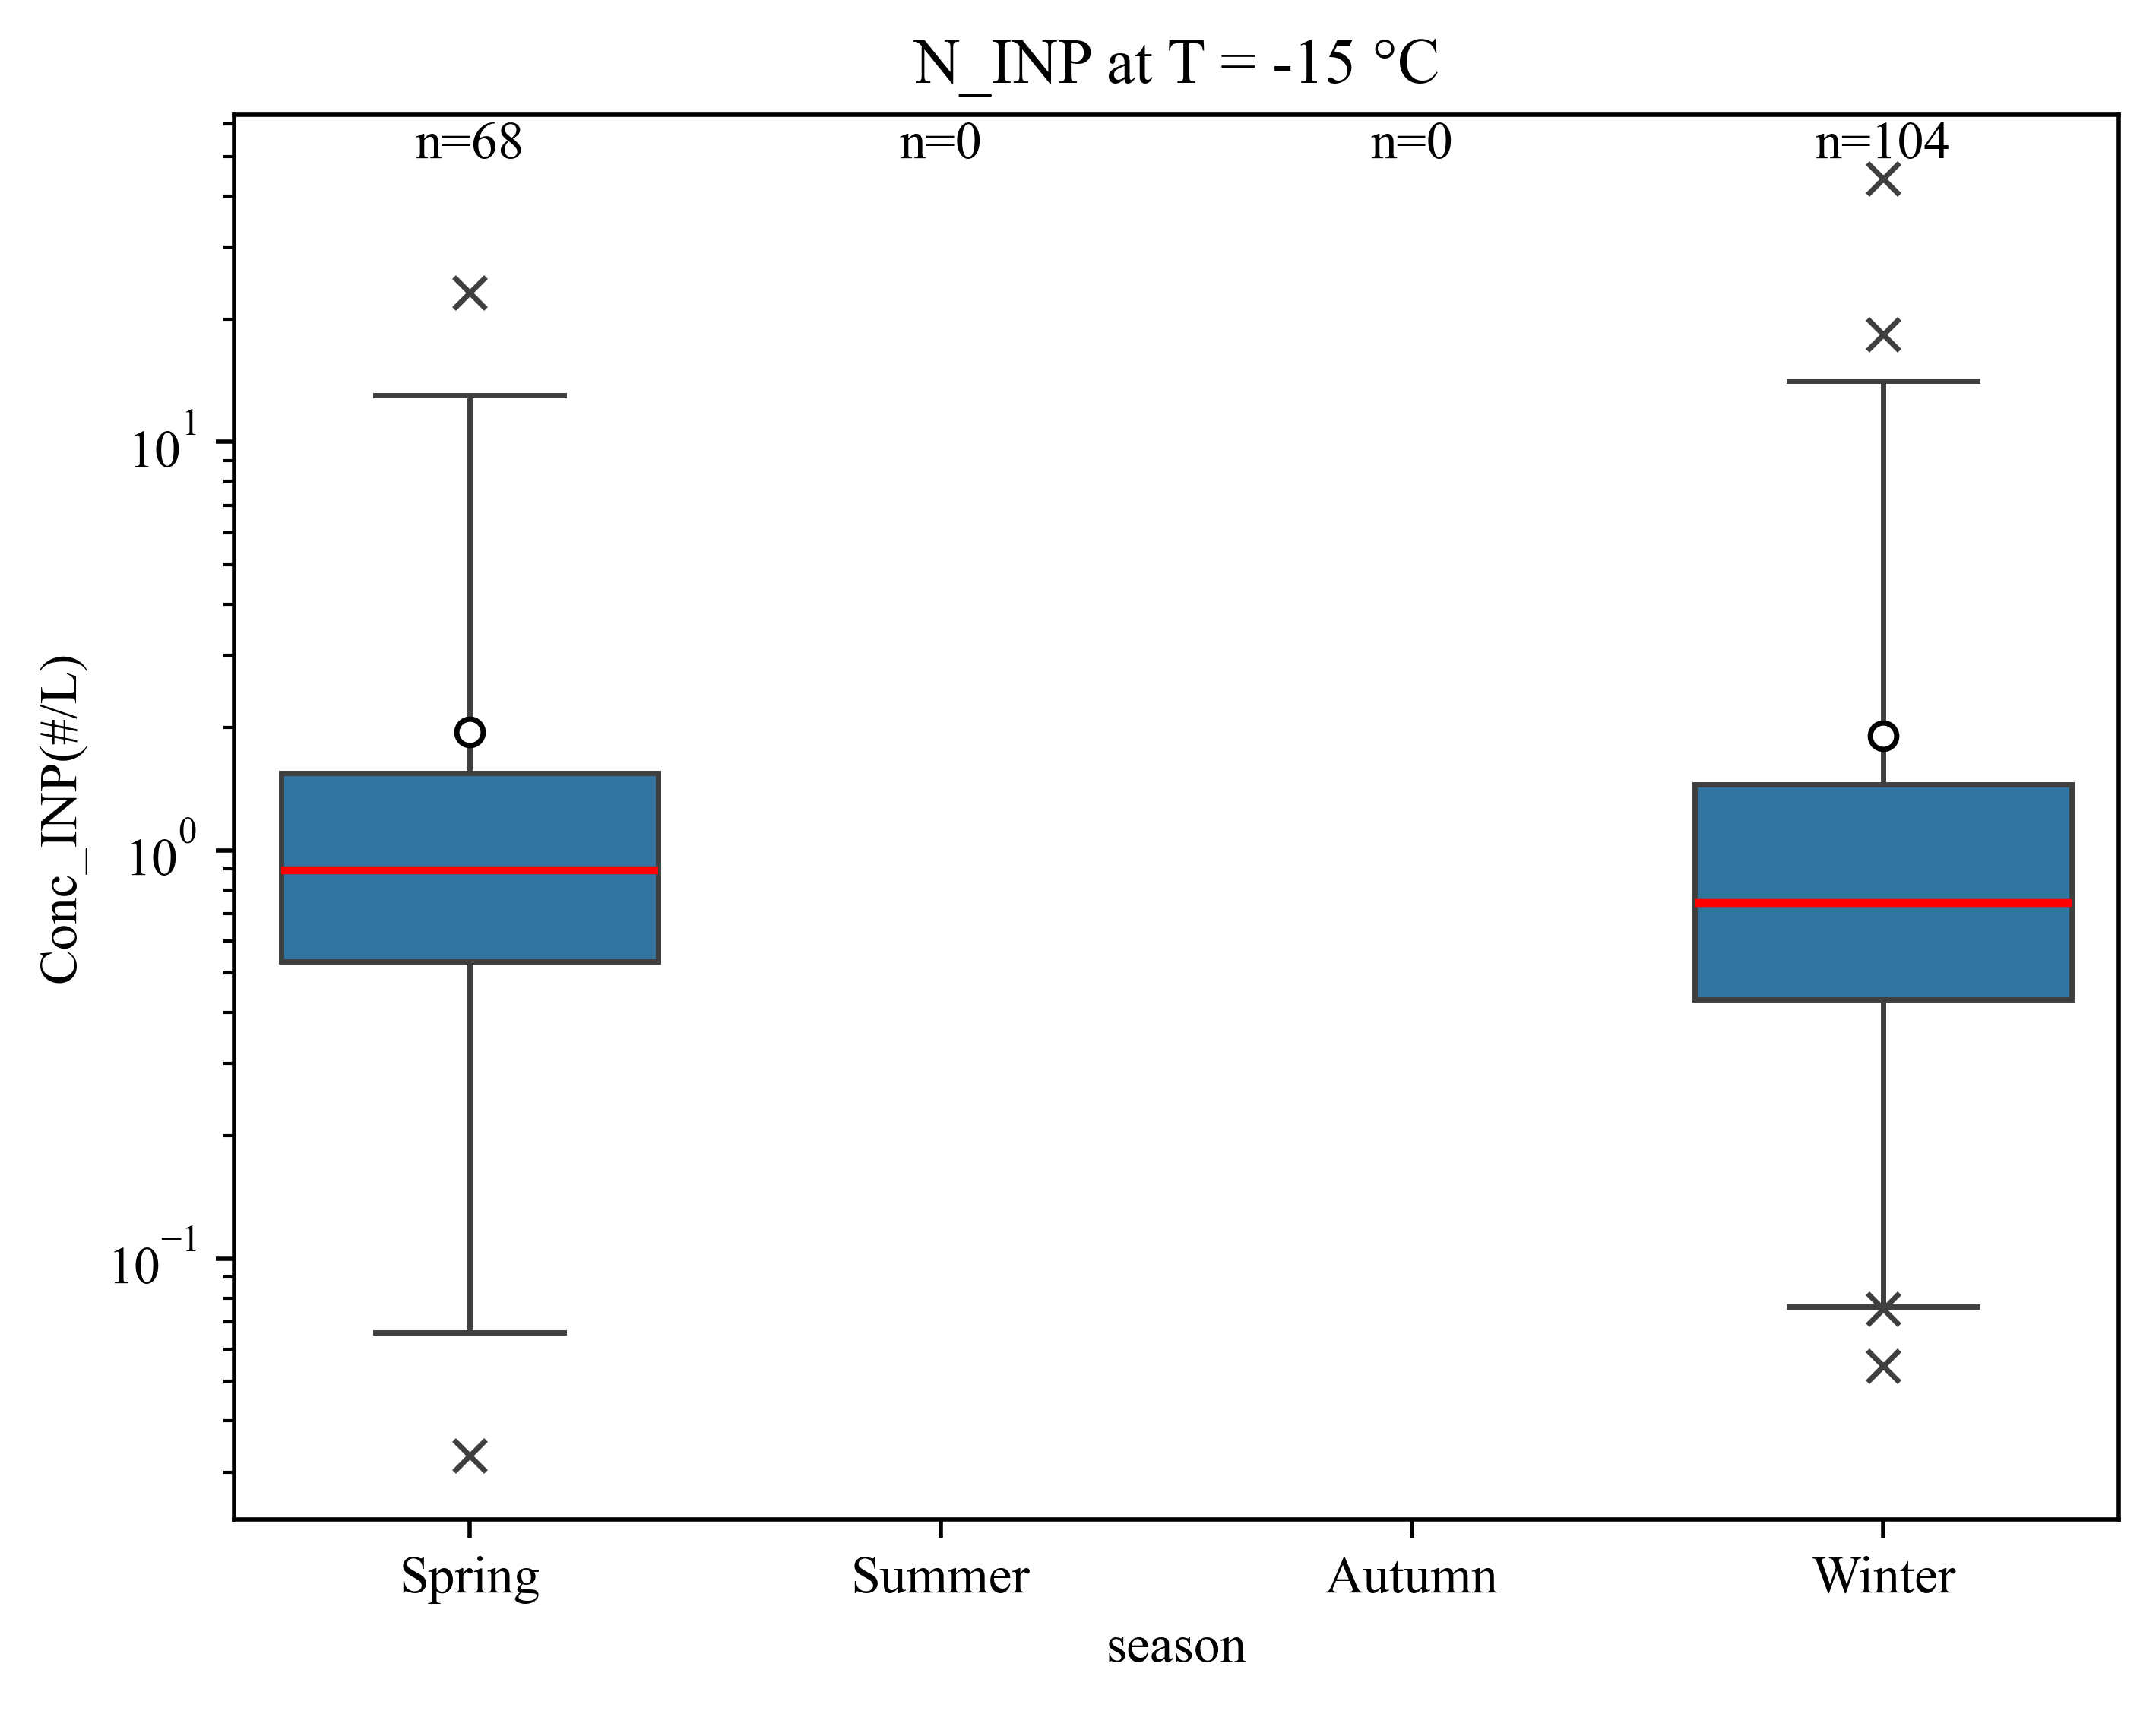

In [6]:
# 使用 seaborn 绘制各个温度下INP浓度的季节箱型图
for i , temp in enumerate(temp_order):
    df_selected = df.where(abs(df['T_inp(°C)'] - temp) < 2.5).dropna()
    df_selected = df_selected[df_selected['N_inp_net(#/L)'] > 0]
    season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

    fig = plt.figure(dpi=500)
    ax = fig.add_subplot(1, 1, 1)
    sns.boxplot(data=df_selected, x='season', y='N_inp_net(#/L)'
                , order=season_order
                , ax=ax
                , showmeans=True
                , meanprops={'marker':'o',
                                'markerfacecolor':'white',
                                'markeredgecolor':'black',
                                'markersize':5
                                }
                , flierprops={"marker": "x"}
                , medianprops={'color':'red', 'linewidth':1.5}
                , whis=[1, 99]
                )
    # 在每个箱形图上方添加数据点数量
    for j, season in enumerate(season_order):
        count = df_selected[df_selected['season'] == season].shape[0]
        ax.text(j, ax.get_ylim()[1]*1, f'n={count}', ha='center', va='bottom')
    ax.set_ylabel('Conc_INP(#/L)')
    ax.set_yscale('log')
    ax.set_title(f'N_INP at T = {temp} °C')

before: (469, 6)
(443, 6)
before: (2081, 6)
(1776, 6)
before: (749, 6)
(568, 6)
before: (720, 6)
(375, 6)
before: (352, 6)
(172, 6)


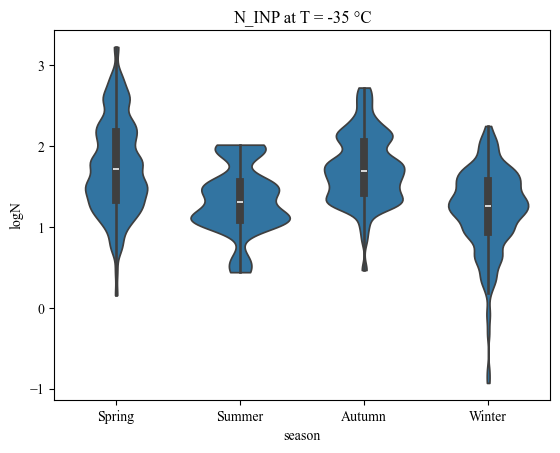

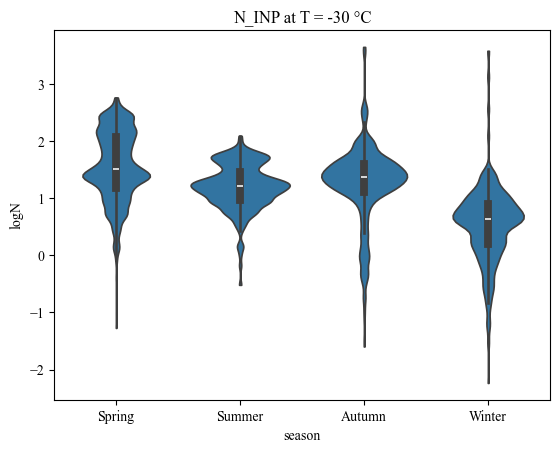

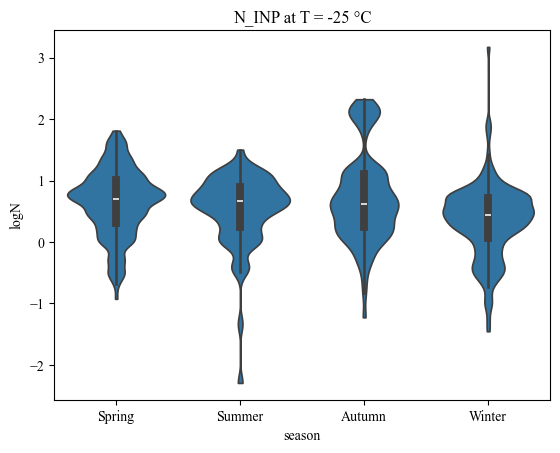

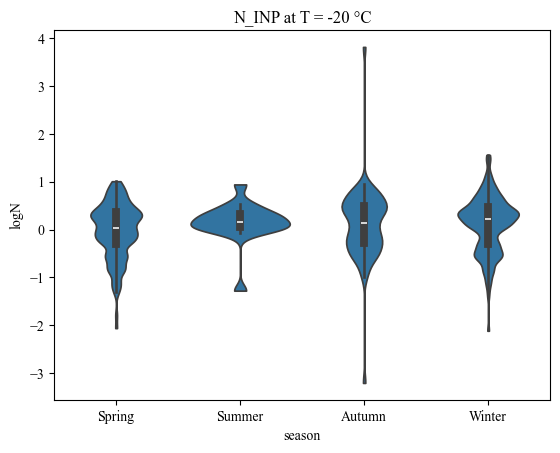

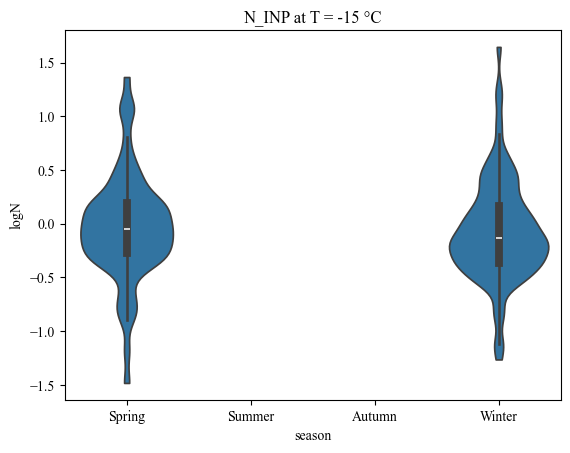

In [7]:
# 使用 seaborn 绘制各个温度下INP浓度的季节小提琴图
for i , temp in enumerate(temp_order):
    df_selected = df.where(abs(df['T_inp(°C)'] - temp) < 2.5).dropna()
    print(f'before: {df_selected.shape}')
    df_selected = df_selected[df_selected['N_inp_net(#/L)'] > 0]
    print(df_selected.shape)
    df_selected["logN"] = np.log10(df_selected["N_inp_net(#/L)"])
    season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    sns.violinplot(data=df_selected, x='season', y='logN'
                , order=season_order
                , ax=ax
                , cut=0, bw_adjust=0.5  # bw_adjust 按需要调
                #, showmeans=True
                #, meanprops={'marker':'o',
                #                'markerfacecolor':'white',
                #                'markeredgecolor':'black',
                #                'markersize':5
                #                }
                #, flierprops={"marker": "x"}
                #, medianprops={'color':'red', 'linewidth':1.5}
                )
    #ax.set_yscale('log')
    ax.set_title(f'N_INP at T = {temp} °C')
